# Exploratory Data Analysis: Raw Data

This notebook analyzes the raw datasets provided for the Store Sales forecasting challenge.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

DATA_DIR = '../data/raw'


## 1. Load Datasets

In [2]:

files = {
    'train': 'train.csv',
    'test': 'test.csv',
    'stores': 'stores.csv',
    'transactions': 'transactions.csv',
    'oil': 'oil.csv',
    'holidays': 'holidays_events.csv'
}

data = {}
for name, file in files.items():
    print(f"Loading {name}...")
    data[name] = pd.read_csv(os.path.join(DATA_DIR, file))
    if 'date' in data[name].columns:
        data[name]['date'] = pd.to_datetime(data[name]['date'])

print("All data loaded.")


Loading train...
Loading test...
Loading stores...
Loading transactions...
Loading oil...
Loading holidays...
All data loaded.


## 2. Dataset Overview
Check shapes and missing values.

In [3]:

for name, df in data.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Missing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")
    display(df.head(3))


--- train ---
Shape: (3000888, 6)
Missing Values:
Series([], dtype: int64)



,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0


--- test ---
Shape: (28512, 5)
Missing Values:
Series([], dtype: int64)



,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2


--- stores ---
Shape: (54, 5)
Missing Values:
Series([], dtype: int64)



...

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358


--- oil ---
Shape: (1218, 2)
Missing Values:
dcoilwtico    43
dtype: int64



,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97


--- holidays ---
Shape: (350, 6)
Missing Values:
Series([], dtype: int64)



,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False


## 3. Target Variable Analysis: Sales
Analyzying the `sales` distribution and trends.

In [4]:

train = data['train']
print(f"Total Sales: {train['sales'].sum():,.0f}")


Total Sales: 1,073,644,952


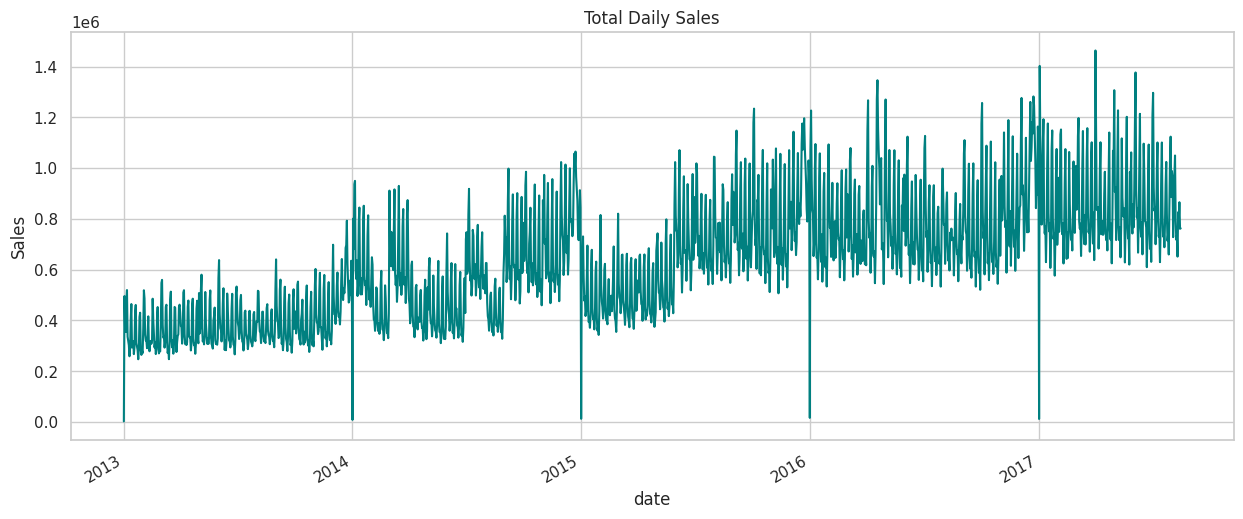

In [5]:

# Sales over time (aggregated)
daily_sales = train.groupby('date')['sales'].sum()
plt.figure()
daily_sales.plot(title='Total Daily Sales', color='teal')
plt.ylabel('Sales')
plt.show()


/tmp/ipykernel_16028/2534043718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_sales.values, y=family_sales.index, palette='viridis')


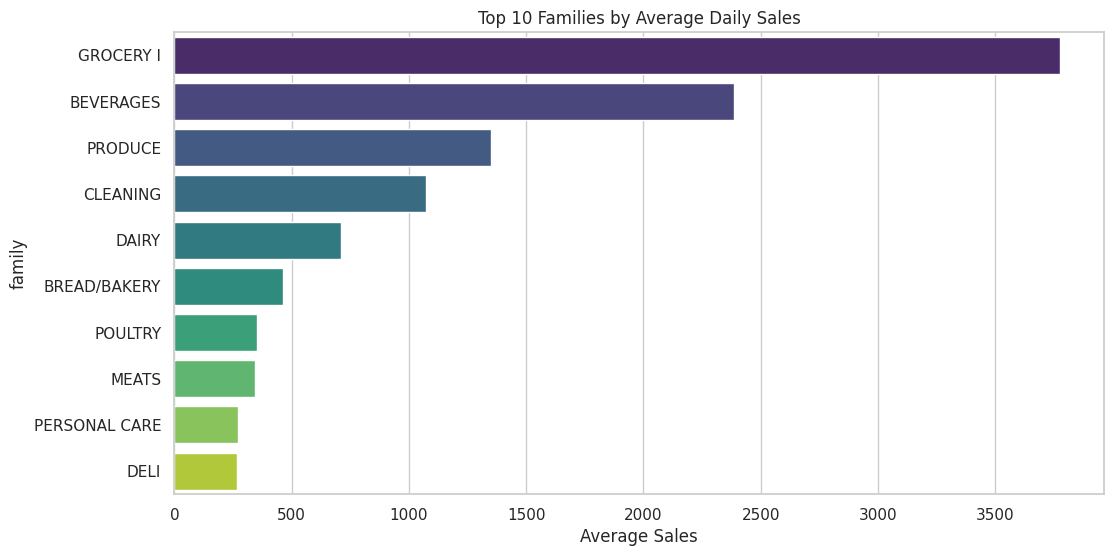

In [6]:

# Sales by Family (Top 10)
family_sales = train.groupby('family')['sales'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=family_sales.values, y=family_sales.index, palette='viridis')
plt.title('Top 10 Families by Average Daily Sales')
plt.xlabel('Average Sales')
plt.show()


## 4. Store Analysis
Analyzing sales by store metadata.

/tmp/ipykernel_16028/2446428625.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_sales.index, y=type_sales.values, palette='magma')


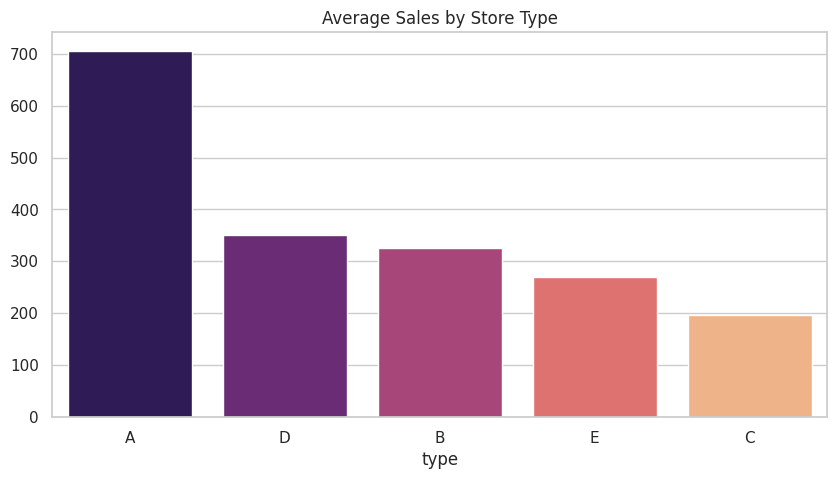

In [7]:

# Merge train with stores
train_stores = train.merge(data['stores'], on='store_nbr', how='left')

# Sales by Store Type
type_sales = train_stores.groupby('type')['sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=type_sales.index, y=type_sales.values, palette='magma')
plt.title('Average Sales by Store Type')
plt.show()


## 5. Oil Prices
Analyzing the oil price trend.

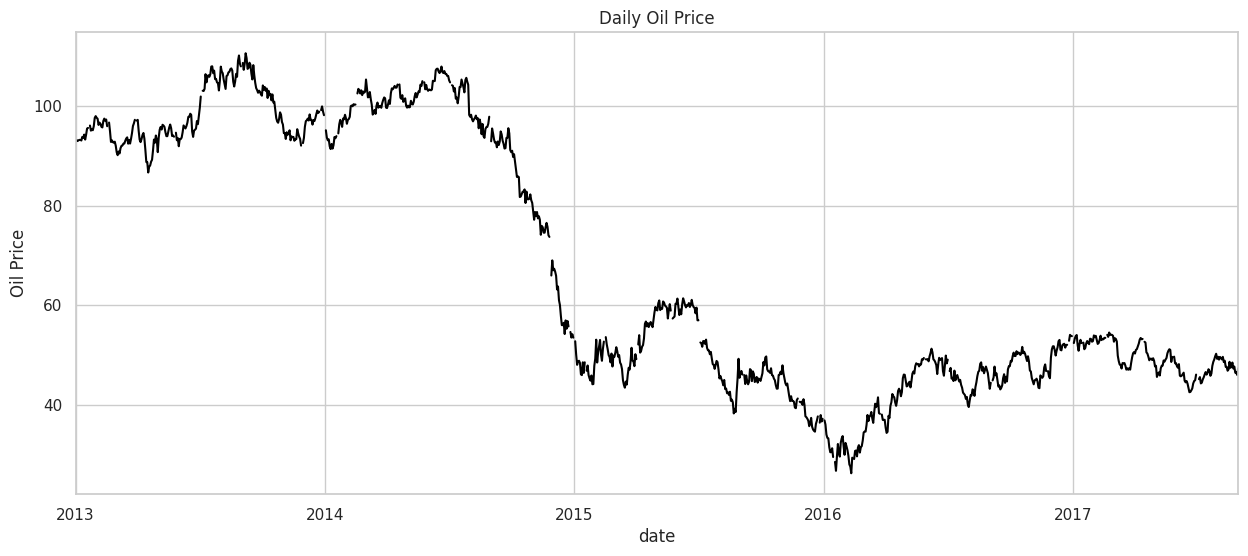

In [8]:

oil = data['oil'].set_index('date')
oil['dcoilwtico'].plot(title='Daily Oil Price', color='black')
plt.ylabel('Oil Price')
plt.show()
